# AVD on the Movement dataset — paper replication

This notebook reproduces the AVD-based classification pipeline from [main.py](main.py) on the **Movement** dataset, using the parameters reported in the paper:

- `dataset` = `"Movement"`
- `w_size` = `10`
- `w_incre` = `1`
- `metric` ∈ {`MAD`, `SD`}

The pipeline is the one summarised in the [README](README.md): load and normalise the multivariate cycles, compute the AVD feature per cycle, reshape into a per-cycle table, and benchmark with `LazyClassifier`. A few plots are added along the way to help interpret each step.

## Imports

In [8]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from lazypredict.Supervised import LazyClassifier

from AVD_function import calculate_AVD_feature

## Paper parameters

These are the values used for the Movement experiments in the paper.

In [9]:
dataset = "Movement"
w_size = 10
w_incre = 1

## 1. Load and prepare the data

Read the aggregated CSV and set `(cycle, time)` as a MultiIndex so each cycle is one full multivariate sample.

In [10]:
data = pd.read_csv(f'data/{dataset}_aggregated_data.csv')

# shift `time` to start at 0 (matches `main.py`)
data['time'] = (data['time'] - 1).astype(int)

data.set_index(['cycle', 'time'], inplace=True)
data.head()

avg_rss12  var_rss12  avg_rss13  var_rss13  avg_rss23  var_rss23  \
cycle time                                                                     
0     0          32.0       4.85      17.50       3.35      22.50       3.20   
      1          40.5       1.12      14.00       2.24      21.75       1.30   
      2          40.5       2.60      11.33       4.50      18.25       5.31   
      3          34.5       1.50      20.67       2.87      19.00       2.83   
      4          34.5       1.50      21.25       3.27      18.25       4.38   

            class  
cycle time         
0     0         0  
      1         0  
      2         0  
      3         0  
      4         0

### Class distribution

How many cycles are there per class? Strongly imbalanced classes can dominate the classification benchmark.

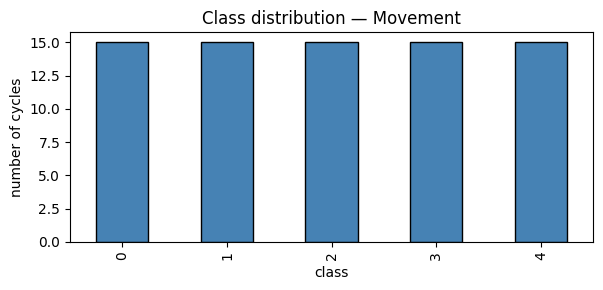

class
0    15
1    15
2    15
3    15
4    15
Name: count, dtype: int64

In [11]:
class_counts = (
    data.reset_index()
    .drop_duplicates(subset='cycle')['class']
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(6, 3))
class_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('class')
ax.set_ylabel('number of cycles')
ax.set_title(f'Class distribution — {dataset}')
plt.tight_layout()
plt.show()
class_counts

### Raw signals for one example cycle

A quick look at what one multivariate sample looks like before any processing.

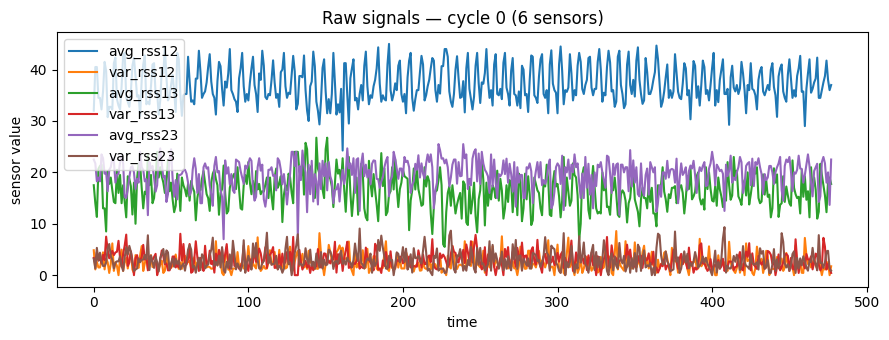

In [12]:
example_cycle = data.index.get_level_values('cycle').unique()[0]
example_raw = data.loc[example_cycle].drop(columns='class', errors='ignore')

fig, ax = plt.subplots(figsize=(9, 3.5))
example_raw.plot(ax=ax, legend=(example_raw.shape[1] <= 10))
ax.set_xlabel('time')
ax.set_ylabel('sensor value')
ax.set_title(f'Raw signals — cycle {example_cycle} ({example_raw.shape[1]} sensors)')
plt.tight_layout()
plt.show()

## 2. Mean-normalise each cycle

Subtract the per-cycle mean from every sensor column. The class label is constant within a cycle, so we keep a separate `class_info_series` and drop the column from the working frame.

In [13]:
sensor_columns = [col for col in data.columns if col != 'class']
print('Sensor columns:', sensor_columns)

mean_per_cycle = data.groupby(level='cycle')[sensor_columns].transform('mean')
normalized_cycles_data = data.copy()
normalized_cycles_data[sensor_columns] = data[sensor_columns] - mean_per_cycle

class_info_series = (
    normalized_cycles_data.reset_index()
    .drop_duplicates(subset='cycle')
    .set_index('cycle')['class']
)
normalized_cycles_data.drop(columns=['class'], inplace=True)
normalized_cycles_data.head()

Sensor columns: ['avg_rss12', 'var_rss12', 'avg_rss13', 'var_rss13', 'avg_rss23', 'var_rss23']


avg_rss12  var_rss12  avg_rss13  var_rss13  avg_rss23  var_rss23
cycle time                                                                  
0     0     -5.174121   2.477699    0.97454   0.443264   2.900669   0.276674
      1      3.325879  -1.252301   -2.52546  -0.666736   2.150669  -1.623326
      2      3.325879   0.227699   -5.19546   1.593264  -1.349331   2.386674
      3     -2.674121  -0.872301    4.14454  -0.036736  -0.599331  -0.093326
      4     -2.674121  -0.872301    4.72454   0.363264  -1.349331   1.456674

### Raw vs. mean-normalised — same example cycle

Mean-normalisation centres each sensor at zero within each cycle, so AVD reflects fluctuations rather than absolute level differences.

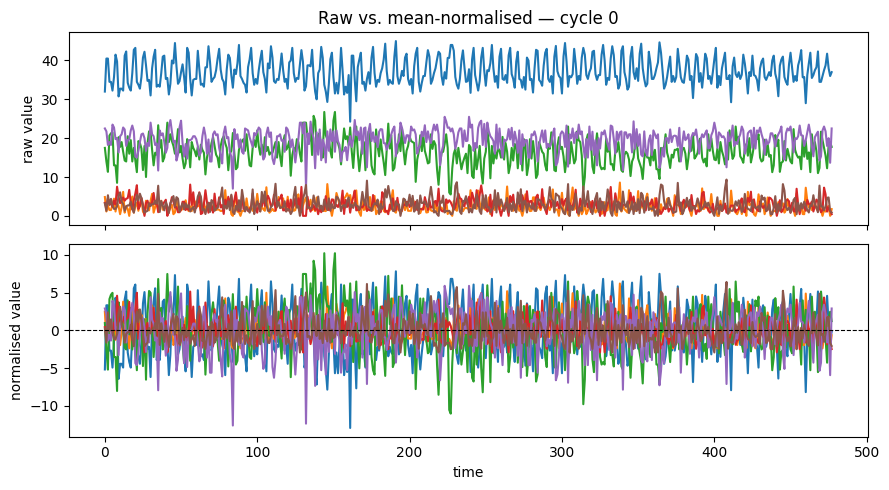

In [14]:
example_norm = normalized_cycles_data.loc[example_cycle]

fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
example_raw.plot(ax=axes[0], legend=False)
axes[0].set_ylabel('raw value')
axes[0].set_title(f'Raw vs. mean-normalised — cycle {example_cycle}')

example_norm.plot(ax=axes[1], legend=False)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('time')
axes[1].set_ylabel('normalised value')

plt.tight_layout()
plt.show()

## 3. Per-metric pipeline

Wrap the AVD computation, reshaping, classification, and per-metric plots into one function so we can run it for both `MAD` and `SD` without duplicating cells.

In [15]:
def run_for_metric(metric, w_size, w_incre):
    # --- 3a) AVD feature per cycle ---
    results_list = []
    cycles = normalized_cycles_data.index.get_level_values('cycle').unique()
    start = time.time()
    for cyc in cycles:
        cycle_data = normalized_cycles_data.loc[cyc]
        avd_for_cycle = calculate_AVD_feature(
            pd.DataFrame(cycle_data), metric=metric, w_size=w_size, w_incre=w_incre
        )
        for time_point, row in avd_for_cycle.iterrows():
            results_list.append((cyc, time_point) + tuple(row.values))
    print(f'AVD calc time ({metric}): {time.time() - start:.2f} s')

    columns = ['cycle', 'time', metric]
    avd_results = pd.DataFrame(results_list, columns=columns)
    avd_results.set_index(['cycle', 'time'], inplace=True)
    avd_results['class'] = avd_results.index.get_level_values('cycle').map(class_info_series)

    # --- 3b) Save and reshape into a per-cycle wide table ---
    save_dir_proc = f'output/Data_Processing_{dataset}'
    os.makedirs(save_dir_proc, exist_ok=True)
    avd_path = f'{save_dir_proc}/avd_results_{metric}_{dataset}.csv'
    avd_results.to_csv(avd_path)

    avd_reloaded = pd.read_csv(avd_path)
    pivot_df = avd_reloaded.pivot_table(index='cycle', columns='time')
    pivot_df = pivot_df.sort_index(axis=1, level=1)
    result_df = pivot_df.stack(level=0)

    class_list = class_info_series.tolist()
    for cycle in result_df.index.levels[0]:
        result_df = result_df.drop(index=(cycle, 'class'))
    result_df['class'] = class_list
    result_df.reset_index(inplace=True)
    result_df.rename(columns={'level_1': 'Metric'}, inplace=True)

    # --- Plot 1: mean AVD curve per class ---
    time_cols = [c for c in result_df.columns if c not in ('cycle', 'Metric', 'class')]
    class_mean_curves = result_df.groupby('class')[time_cols].mean()

    fig, ax = plt.subplots(figsize=(9, 3.5))
    for cls, row in class_mean_curves.iterrows():
        ax.plot(time_cols, row.values, label=str(cls))
    ax.set_xlabel('time (window end)')
    ax.set_ylabel(f'mean AVD ({metric})')
    ax.set_title(f'Mean AVD curve per class — {dataset} / {metric}')
    if class_mean_curves.shape[0] <= 12:
        ax.legend(title='class', loc='best', fontsize=8)
    plt.tight_layout()
    plt.show()

    # --- 3c) LazyPredict classification benchmark ---
    save_dir_results = f'output/Results_{dataset}'
    os.makedirs(save_dir_results, exist_ok=True)

    X = result_df.drop(['class', 'cycle', 'Metric'], axis=1)
    y = result_df['class']
    y_encoded = LabelEncoder().fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.3, random_state=42
    )
    X_train = np.array(X_train, dtype=float)
    X_test = np.array(X_test, dtype=float)

    clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
    models, _ = clf.fit(X_train, X_test, y_train, y_test)

    out_path = os.path.join(save_dir_results, f'Classification_Result_{metric}.csv')
    models.to_csv(out_path)
    print(f'Classification results saved to {out_path}')

    # --- Plot 2: top-10 classifier accuracies ---
    top10 = models['Accuracy'].head(10).iloc[::-1]
    fig, ax = plt.subplots(figsize=(7, 4))
    top10.plot(kind='barh', ax=ax, color='seagreen', edgecolor='black')
    ax.set_xlabel('accuracy')
    ax.set_title(f'Top-10 classifiers by accuracy — {dataset} / {metric}')
    ax.set_xlim(0, 1)
    for i, v in enumerate(top10.values):
        ax.text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

    return models

## 4. Run with `MAD`

Paper parameters for Movement: `metric="MAD"`, `w_size=10`, `w_incre=1`.

AVD calc time (MAD): 3.01 s


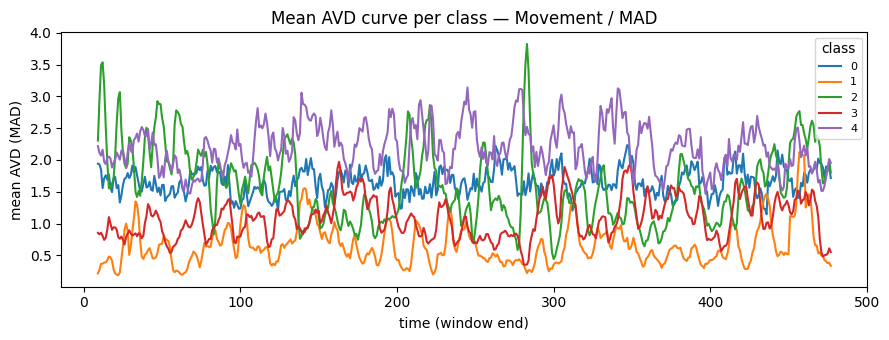

Classification results saved to output/Results_Movement/Classification_Result_MAD.csv


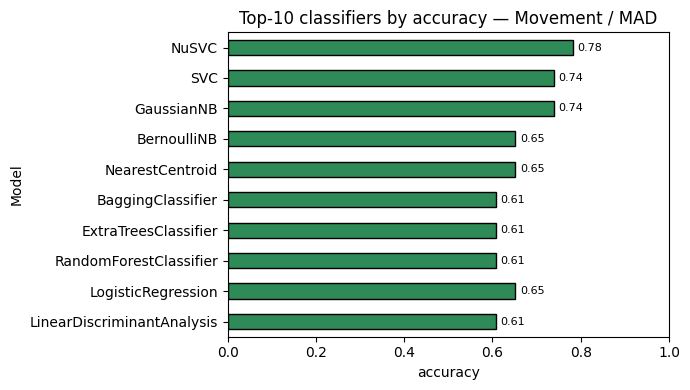

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
NuSVC,0.782609,0.816667,NaN,0.797308,0.885714,0.782609,0.012556
SVC,0.739130,0.783333,NaN,0.756315,0.879917,0.739130,0.016896
GaussianNB,0.739130,0.766667,0.929942,0.739556,0.822826,0.739130,0.024182
BernoulliNB,0.652174,0.726667,0.939928,0.620428,0.782609,0.652174,0.013618
NearestCentroid,0.652174,0.666667,0.925603,0.558740,0.494203,0.652174,0.041890
BaggingClassifier,0.608696,0.633333,0.827549,0.550725,0.546584,0.608696,0.040157
ExtraTreesClassifier,0.608696,0.616667,0.951702,0.570048,0.558799,0.608696,0.103795
RandomForestClassifier,0.608696,0.610000,0.914851,0.601581,0.695652,0.608696,0.076825
LogisticRegression,0.652174,0.600000,0.825539,0.615942,0.753106,0.652174,0.097943


In [16]:
models_mad = run_for_metric('MAD', w_size, w_incre)
models_mad

## 5. Run with `SD`

Paper parameters for Movement: `metric="SD"`, `w_size=10`, `w_incre=1`.

AVD calc time (SD): 2.34 s


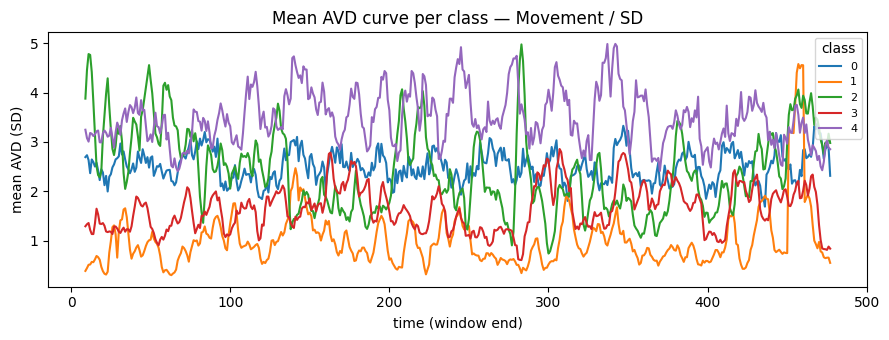

Classification results saved to output/Results_Movement/Classification_Result_SD.csv


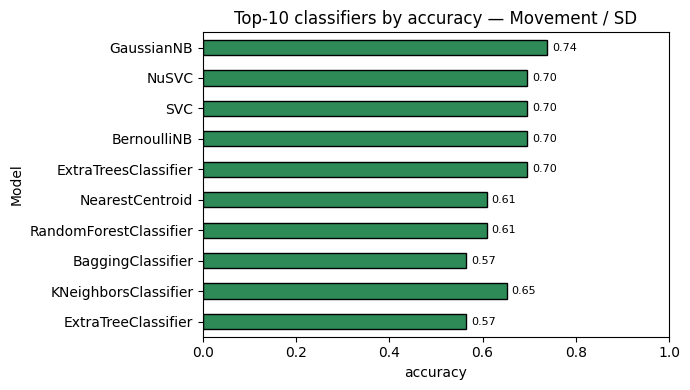

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
GaussianNB,0.739130,0.766667,0.921122,0.745210,0.833540,0.739130,0.013360
NuSVC,0.695652,0.743333,NaN,0.715867,0.804348,0.695652,0.019128
SVC,0.695652,0.743333,NaN,0.715867,0.804348,0.695652,0.014454
BernoulliNB,0.695652,0.700000,0.932428,0.688406,0.814700,0.695652,0.014688
ExtraTreesClassifier,0.695652,0.683333,0.931129,0.719048,0.824845,0.695652,0.060555
NearestCentroid,0.608696,0.633333,0.891868,0.518357,0.453830,0.608696,0.021771
RandomForestClassifier,0.608696,0.633333,0.917233,0.526350,0.485093,0.608696,0.075588
BaggingClassifier,0.565217,0.600000,0.762672,0.479487,0.457212,0.565217,0.041430
KNeighborsClassifier,0.652174,0.600000,0.842102,0.536740,0.476923,0.652174,0.056702


In [17]:
models_sd = run_for_metric('SD', w_size, w_incre)
models_sd